In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from IQAEBinom_OnlyFinalRound_EndCIReachTol import IQAEBinom_OnlyFinalRound_EndCIReachTol

In [2]:
nShotUnit = 1
epsilon = 0.001
alpha = 0.05

In [3]:
pTrue = 0.2505
thetaTrue = np.arcsin(np.sqrt(pTrue))

In [4]:
# 次のroundに行く場合はNaNとする
nEstim = 10000
minRatio = 2
nGrovers = np.arange(200, 701, 10)
angleFracs = np.linspace(0, 1, num=42)[1:-1] # (2*nGrov + 1) * theta / pi の小数部分の意
resDf = pd.DataFrame(columns=["nGrover","r","AngleFrac","Bias","NumSamp","NumEnd"])

for nGrover in nGrovers:

    r = int((2 * nGrover + 1) * thetaTrue / np.pi)

    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = (r + angleFrac) * np.pi / (2 * nGrover + 1)
        p = np.sin(thetaTemp) ** 2
        errs = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2)
            if result is None:
                errs.append(np.nan)
            else:
                pEst = result["Estimate"]
                errs.append(pEst - p)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errs)
        numSamp = len(errs)
        numEnd = numSamp - np.sum(np.isnan(errs))
        resDf = resDf.append(pd.Series([nGrover,r,angleFrac,errMean,numSamp,numEnd], index=resDf.columns), ignore_index=True)

200 0.024390243902439025 2023-09-13 09:56:03.457561
200 0.04878048780487805 2023-09-13 09:56:09.562818
200 0.07317073170731708 2023-09-13 09:56:15.437900
200 0.0975609756097561 2023-09-13 09:56:21.772811
200 0.12195121951219512 2023-09-13 09:56:27.289380
200 0.14634146341463417 2023-09-13 09:56:32.403607
200 0.17073170731707318 2023-09-13 09:56:37.468412
200 0.1951219512195122 2023-09-13 09:56:42.813203
200 0.21951219512195122 2023-09-13 09:56:47.721000
200 0.24390243902439024 2023-09-13 09:56:52.428657
200 0.2682926829268293 2023-09-13 09:56:56.995391
200 0.29268292682926833 2023-09-13 09:57:02.044022
200 0.3170731707317073 2023-09-13 09:57:06.999054
200 0.34146341463414637 2023-09-13 09:57:12.123743
200 0.36585365853658536 2023-09-13 09:57:18.516783
200 0.3902439024390244 2023-09-13 09:57:24.063421
200 0.41463414634146345 2023-09-13 09:57:31.603189
200 0.43902439024390244 2023-09-13 09:57:36.168596
200 0.4634146341463415 2023-09-13 09:57:38.939109
200 0.4878048780487805 2023-09-13 09

<ipython-input-4-8a069ba26618>:26: RuntimeWarning: Mean of empty slice
  errMean = np.nanmean(errs)


210 0.5365853658536586 2023-09-13 10:09:42.778922
210 0.5609756097560976 2023-09-13 10:09:46.487086
210 0.5853658536585367 2023-09-13 10:09:49.902851
210 0.6097560975609756 2023-09-13 10:09:53.262933
210 0.6341463414634146 2023-09-13 10:09:56.484385
210 0.6585365853658537 2023-09-13 10:10:00.136719
210 0.6829268292682927 2023-09-13 10:10:04.436816
210 0.7073170731707318 2023-09-13 10:10:08.775832
210 0.7317073170731707 2023-09-13 10:10:13.249385
210 0.7560975609756098 2023-09-13 10:10:17.443601
210 0.7804878048780488 2023-09-13 10:10:23.590519
210 0.8048780487804879 2023-09-13 10:10:28.114451
210 0.8292682926829269 2023-09-13 10:10:32.612360
210 0.8536585365853658 2023-09-13 10:10:37.025433
210 0.8780487804878049 2023-09-13 10:10:41.464837
210 0.9024390243902439 2023-09-13 10:10:45.558386
210 0.926829268292683 2023-09-13 10:10:50.014622
210 0.951219512195122 2023-09-13 10:10:54.582791
210 0.975609756097561 2023-09-13 10:10:59.551981
220 0.024390243902439025 2023-09-13 10:11:04.732493
2

In [5]:
resDf.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/Bias_VariousNGrovAngleFrac_p0.2505_nG200-700.csv", index=False)

In [3]:
resDf = pd.read_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230914_Bias_VariousNGrovAngleFrac/Bias_VariousNGrovAngleFrac_p0.2505.csv")

In [4]:
resDf[resDf['nGrover'] == 300]

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
1800,300.0,100.0,0.024390,-6.898673e-05,10000.0,10000.0
1801,300.0,100.0,0.048780,-7.059000e-05,10000.0,10000.0
1802,300.0,100.0,0.073171,-4.162464e-05,10000.0,10000.0
1803,300.0,100.0,0.097561,-1.060669e-05,10000.0,10000.0
1804,300.0,100.0,0.121951,4.693590e-07,10000.0,10000.0
1805,300.0,100.0,0.146341,-1.504399e-05,10000.0,10000.0
1806,300.0,100.0,0.170732,-2.423767e-05,10000.0,10000.0
1807,300.0,100.0,0.195122,-2.952179e-05,10000.0,10000.0
1808,300.0,100.0,0.219512,-2.709955e-05,10000.0,10000.0
1809,300.0,100.0,0.243902,-8.712436e-06,10000.0,10000.0


In [6]:
resDf

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
0,120.0,40.0,0.024390,0.000696,10000.0,1.0
1,120.0,40.0,0.048780,0.000440,10000.0,198.0
2,120.0,40.0,0.073171,0.000166,10000.0,1928.0
3,120.0,40.0,0.097561,-0.000109,10000.0,2382.0
4,120.0,40.0,0.121951,-0.000384,10000.0,596.0
...,...,...,...,...,...,...
3435,700.0,233.0,0.878049,0.000095,10000.0,10000.0
3436,700.0,233.0,0.902439,0.000097,10000.0,10000.0
3437,700.0,233.0,0.926829,0.000093,10000.0,10000.0
3438,700.0,233.0,0.951220,0.000071,10000.0,10000.0


In [7]:
resDf["Bias"]

0       0.000665
1       0.000506
2       0.000356
3       0.000212
4       0.000083
          ...   
2035    0.000095
2036    0.000097
2037    0.000093
2038    0.000071
2039    0.000041
Name: Bias, Length: 2040, dtype: float64

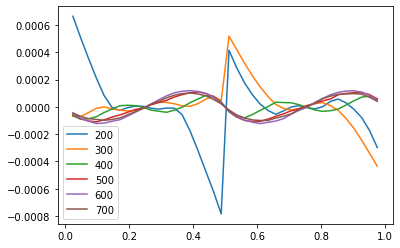

In [8]:
ax = plt.gca()
for nG in [200, 300, 400, 500, 600, 700]:
    resDfPart = resDf[resDf["nGrover"] == nG]
    plt.plot(resDfPart["AngleFrac"], resDfPart["Bias"], label=str(nG))
plt.legend()
plt.show()

In [8]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230830_IQAEVariousP_nShotUnit1/results_IQAE_pTrue0.25049999999999994_epsilon0001_alpha005.dat", 'rb') as f:
    results02505 = pickle.load(f)

In [9]:
nGroversExp = np.array([r["nGrover"][-1] for r in results02505])
angleFracExp = np.modf((2 * nGroversExp + 1) * thetaTrue / np.pi)[0]

In [11]:
np.unique(nGroversExp, return_counts=True)

(array([116, 119, 122, 123, 125, 126, 128, 129, 131, 132, 134, 135, 137,
        138, 140, 141, 143, 144, 146, 147, 149, 150, 152, 153, 155, 156,
        158, 159, 161, 162, 164, 165, 167, 168, 170, 171, 173, 174, 176,
        177, 179, 180, 182, 183, 185, 186, 187, 188, 189, 191, 192, 193,
        194, 195, 196, 197, 198, 199, 200, 201, 203, 204, 205, 206, 207,
        209, 210, 212, 213, 214, 216, 217, 218, 219, 220, 221, 222, 223,
        224, 225, 226, 227, 228, 230, 231, 232, 233, 234, 235, 236, 237,
        238, 239, 240, 241, 242, 243, 244, 245, 246, 248, 249, 250, 251,
        252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264,
        265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277,
        278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290,
        291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303,
        304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316,
        317, 318, 319, 320, 321, 322, 323, 324, 325

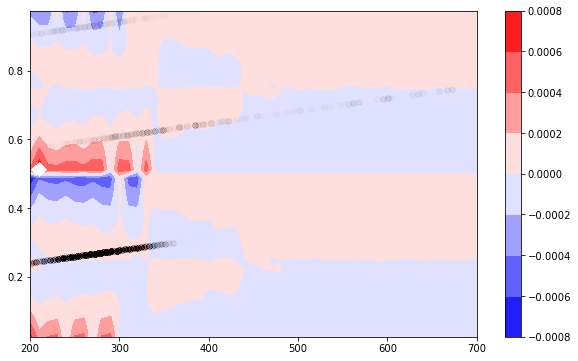

In [12]:
fig, ax1 = plt.subplots(1,figsize=(10,6))

ax1.contourf(nGrovers, angleFracs, np.reshape(np.array(resDf["Bias"]), (len(nGrovers), len(angleFracs))).T, cmap="bwr")    #等高線表示
cntr1 = ax1.contourf(nGrovers, angleFracs, np.reshape(np.array(resDf["Bias"]), (len(nGrovers), len(angleFracs))).T, cmap="bwr")
fig.colorbar(cntr1, ax=ax1)

#ax1 = plt.colorbar(label="contour level")

ax1.scatter(nGroversExp,angleFracExp, c="k", alpha=0.005)

ax1.set_xlim(200,700)

plt.show()

In [48]:
nGrovers = np.arange(120, 191, 10)
angleFracs = np.linspace(0, 1, num=42)[1:-1] # (2*nGrov + 1) * theta / pi の小数部分の意
resDf2 = pd.DataFrame(columns=["nGrover","r","AngleFrac","Bias","NumSamp","NumEnd"])

for nGrover in nGrovers:

    r = int((2 * nGrover + 1) * thetaTrue / np.pi)

    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = (r + angleFrac) * np.pi / (2 * nGrover + 1)
        p = np.sin(thetaTemp) ** 2
        errs = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2)
            if result is None:
                errs.append(np.nan)
            else:
                pEst = result["Estimate"]
                errs.append(pEst - p)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errs)
        numSamp = len(errs)
        numEnd = numSamp - np.sum(np.isnan(errs))
        resDf2 = resDf2.append(pd.Series([nGrover,r,angleFrac,errMean,numSamp,numEnd], index=resDf.columns), ignore_index=True)

120 0.024390243902439025 2023-09-13 13:51:07.260843
120 0.04878048780487805 2023-09-13 13:52:40.200250
120 0.07317073170731708 2023-09-13 13:54:20.320343
120 0.0975609756097561 2023-09-13 13:56:26.308246
120 0.12195121951219512 2023-09-13 13:59:44.018234
120 0.14634146341463417 2023-09-13 14:02:58.938255
120 0.17073170731707318 2023-09-13 14:04:16.761729
120 0.1951219512195122 2023-09-13 14:04:45.655474
120 0.21951219512195122 2023-09-13 14:05:03.954778
120 0.24390243902439024 2023-09-13 14:05:18.609136
120 0.2682926829268293 2023-09-13 14:05:34.222959
120 0.29268292682926833 2023-09-13 14:05:48.045647
120 0.3170731707317073 2023-09-13 14:06:00.933670
120 0.34146341463414637 2023-09-13 14:06:17.417374


<ipython-input-48-b4646096011e>:23: RuntimeWarning: Mean of empty slice
  errMean = np.nanmean(errs)


120 0.36585365853658536 2023-09-13 14:06:47.668375
120 0.3902439024390244 2023-09-13 14:07:38.198401
120 0.41463414634146345 2023-09-13 14:08:18.317423
120 0.43902439024390244 2023-09-13 14:08:46.883473
120 0.4634146341463415 2023-09-13 14:09:09.258217
120 0.4878048780487805 2023-09-13 14:09:28.812179
120 0.5121951219512195 2023-09-13 14:09:47.162895
120 0.5365853658536586 2023-09-13 14:09:50.431238
120 0.5609756097560976 2023-09-13 14:09:54.299191
120 0.5853658536585367 2023-09-13 14:09:57.928705
120 0.6097560975609756 2023-09-13 14:10:02.057968
120 0.6341463414634146 2023-09-13 14:10:07.185798
120 0.6585365853658537 2023-09-13 14:10:13.290679
120 0.6829268292682927 2023-09-13 14:10:20.773341
120 0.7073170731707318 2023-09-13 14:10:28.570013
120 0.7317073170731707 2023-09-13 14:10:36.407403
120 0.7560975609756098 2023-09-13 14:10:43.752263
120 0.7804878048780488 2023-09-13 14:10:51.129492
120 0.8048780487804879 2023-09-13 14:10:58.811013
120 0.8292682926829269 2023-09-13 14:11:07.8097

In [49]:
resDf2.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/Bias_VariousNGrovAngleFrac_p0.2505_nG120-190.csv", index=False)

In [50]:
resDfComb = resDf.append(resDf2)

In [51]:
resDfComb = resDfComb.sort_values(by=["nGrover","AngleFrac"])

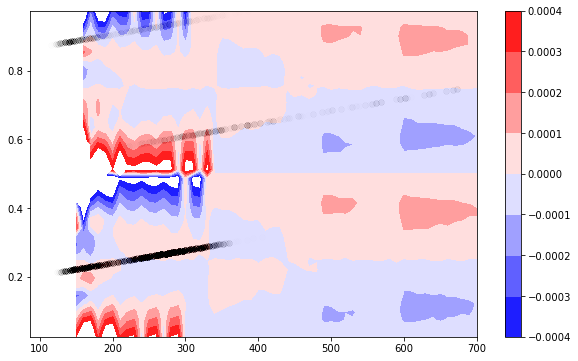

In [52]:
nGrovers = np.arange(120, 701, 10)

fig, ax1 = plt.subplots(1,figsize=(10,6))

levels = np.arange(-0.0004, 0.00041, 0.0001)

ax1.contourf(nGrovers, angleFracs, np.reshape(np.array(resDfComb["Bias"]), (len(nGrovers), len(angleFracs))).T, cmap="bwr", levels=levels)    #等高線表示
cntr1 = ax1.contourf(nGrovers, angleFracs, np.reshape(np.array(resDfComb["Bias"]), (len(nGrovers), len(angleFracs))).T, cmap="bwr", levels=levels)
fig.colorbar(cntr1, ax=ax1)

#ax1 = plt.colorbar(label="contour level")

ax1.scatter(nGroversExp,angleFracExp, c="k", alpha=0.005)

plt.show()

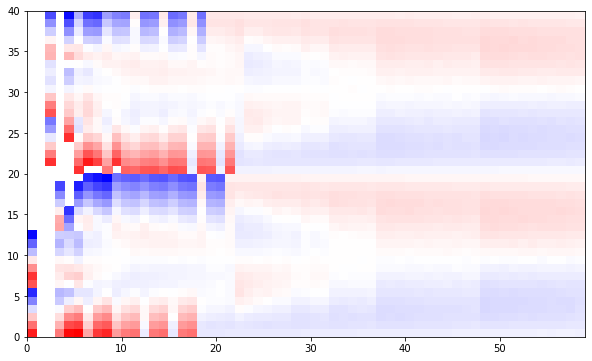

In [53]:
fig, ax = plt.subplots(figsize=(10,6))
biasMat = np.reshape(np.array(resDfComb["Bias"]), (len(nGrovers), len(angleFracs))).T
heatmap = ax.pcolor(biasMat, cmap="bwr")

# ax.set_xticks(np.arange(biasMat.shape[0]) + 0.5, minor=False)
# ax.set_yticks(np.arange(biasMat.shape[1]) + 0.5, minor=False)

# ax.invert_yaxis()
# ax.xaxis.tick_top()

# ax.set_xticklabels(row_labels, minor=False)
# ax.set_yticklabels(column_labels, minor=False)
plt.show()

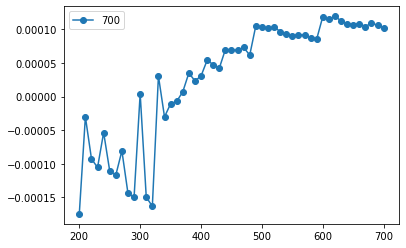

In [55]:
ax = plt.gca()
resDfPart = resDf[np.abs(resDf["AngleFrac"] - 0.390244) < 1e-5]
plt.plot(resDfPart["nGrover"], resDfPart["Bias"], label=str(nG), marker="o")
plt.legend()
plt.show()

nGrover=120とかで終了しているケースがあるのに、なぜOnlyFinalだと終了しない？

In [81]:
# pTrueでテスト
results = []
errs = []
for i in range(nEstim):
    result = IQAEBinom_OnlyFinalRound_EndCIReachTol(pTrue, 128, epsilon, alpha, nShotUnit, minRatio=2)
    pEst = result["Estimate"]
    errs.append(pEst - pTrue)
    results.append(result)
errMean = np.nanmean(errs)
numSamp = len(errs)
numEnd = numSamp - np.sum(np.isnan(errs))

In [82]:
print(errMean, numEnd)

0.0003105543192943271 1952


In [83]:
resDfComb[resDfComb["nGrover"]==120]

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
0,120.0,40.0,0.024390,0.000696,10000.0,1.0
1,120.0,40.0,0.048780,0.000440,10000.0,198.0
2,120.0,40.0,0.073171,0.000166,10000.0,1928.0
3,120.0,40.0,0.097561,-0.000109,10000.0,2382.0
4,120.0,40.0,0.121951,-0.000384,10000.0,596.0
5,120.0,40.0,0.146341,-0.000660,10000.0,45.0
6,120.0,40.0,0.170732,0.000524,10000.0,5.0
7,120.0,40.0,0.195122,0.000620,10000.0,38.0
8,120.0,40.0,0.219512,0.000345,10000.0,107.0
9,120.0,40.0,0.243902,0.000069,10000.0,239.0


In [85]:
np.modf((2 * 120 + 1) * thetaTrue / np.pi)

(0.21094201089779574, 40.0)

pTrue近傍は終了している

In [8]:
nGrovers = np.arange(120, 150)
nGrovers = nGrovers[nGrovers % 10 != 0]
angleFracs = np.linspace(0, 1, num=42)[1:-1] # (2*nGrov + 1) * theta / pi の小数部分の意
resDf3 = pd.DataFrame(columns=["nGrover","r","AngleFrac","Bias","NumSamp","NumEnd"])

for nGrover in nGrovers:

    r = int((2 * nGrover + 1) * thetaTrue / np.pi)

    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = (r + angleFrac) * np.pi / (2 * nGrover + 1)
        p = np.sin(thetaTemp) ** 2
        errs = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2)
            if result is None:
                errs.append(np.nan)
            else:
                pEst = result["Estimate"]
                errs.append(pEst - p)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errs)
        numSamp = len(errs)
        numEnd = numSamp - np.sum(np.isnan(errs))
        resDf3 = resDf3.append(pd.Series([nGrover,r,angleFrac,errMean,numSamp,numEnd], index=resDf3.columns), ignore_index=True)
        resDf3.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/Bias_VariousNGrovAngleFrac_p0.2505_nG120-150Detail.csv", index=False)

121 0.024390243902439025 2023-09-14 08:37:24.227206


<ipython-input-8-256ff3aec5b5>:24: RuntimeWarning: Mean of empty slice
  errMean = np.nanmean(errs)


121 0.04878048780487805 2023-09-14 08:37:33.135693
121 0.07317073170731708 2023-09-14 08:37:45.066165
121 0.0975609756097561 2023-09-14 08:38:02.944062
121 0.12195121951219512 2023-09-14 08:38:24.565957
121 0.14634146341463417 2023-09-14 08:38:55.810268
121 0.17073170731707318 2023-09-14 08:39:21.092693
121 0.1951219512195122 2023-09-14 08:39:44.079564
121 0.21951219512195122 2023-09-14 08:39:56.110896
121 0.24390243902439024 2023-09-14 08:40:08.709961
121 0.2682926829268293 2023-09-14 08:40:18.221456
121 0.29268292682926833 2023-09-14 08:40:27.605200
121 0.3170731707317073 2023-09-14 08:40:37.965758
121 0.34146341463414637 2023-09-14 08:40:49.128388
121 0.36585365853658536 2023-09-14 08:40:59.013185
121 0.3902439024390244 2023-09-14 08:41:05.542978
121 0.41463414634146345 2023-09-14 08:41:10.369755
121 0.43902439024390244 2023-09-14 08:41:14.147419
121 0.4634146341463415 2023-09-14 08:41:17.610349
121 0.4878048780487805 2023-09-14 08:41:20.715958
121 0.5121951219512195 2023-09-14 08:4

In [4]:
resDfComb = pd.read_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230914_Bias_VariousNGrovAngleFrac/Bias_VariousNGrovAngleFrac_p0.2505.csv")

In [10]:
resDfComb

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
0,120.0,40.0,0.024390,0.000696,10000.0,1.0
1,120.0,40.0,0.048780,0.000440,10000.0,198.0
2,120.0,40.0,0.073171,0.000166,10000.0,1928.0
3,120.0,40.0,0.097561,-0.000109,10000.0,2382.0
4,120.0,40.0,0.121951,-0.000384,10000.0,596.0
...,...,...,...,...,...,...
3435,700.0,233.0,0.878049,0.000095,10000.0,10000.0
3436,700.0,233.0,0.902439,0.000097,10000.0,10000.0
3437,700.0,233.0,0.926829,0.000093,10000.0,10000.0
3438,700.0,233.0,0.951220,0.000071,10000.0,10000.0


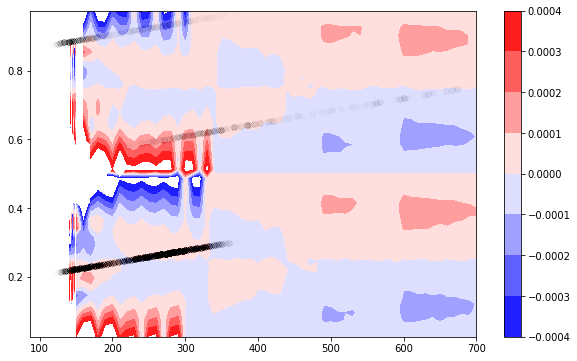

In [10]:
nGrovers = np.unique(resDfComb["nGrover"])
angleFracs = np.linspace(0, 1, num=42)[1:-1] # (2*nGrov + 1) * theta / pi の小数部分の意

fig, ax1 = plt.subplots(1,figsize=(10,6))

levels = np.arange(-0.0004, 0.00041, 0.0001)

ax1.contourf(nGrovers, angleFracs, np.reshape(np.array(resDfComb["Bias"]), (len(nGrovers), len(angleFracs))).T, cmap="bwr", levels=levels)    #等高線表示
cntr1 = ax1.contourf(nGrovers, angleFracs, np.reshape(np.array(resDfComb["Bias"]), (len(nGrovers), len(angleFracs))).T, cmap="bwr", levels=levels)
fig.colorbar(cntr1, ax=ax1)

#ax1 = plt.colorbar(label="contour level")

ax1.scatter(nGroversExp,angleFracExp, c="k", alpha=0.005)

plt.show()

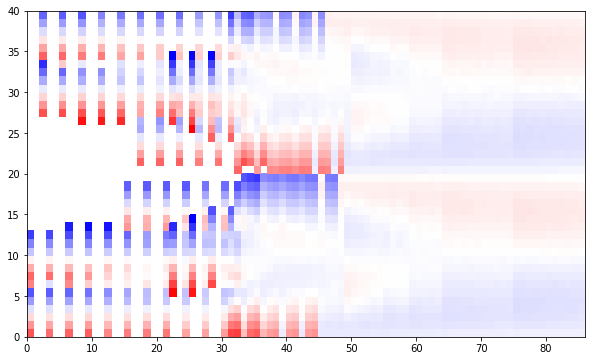

In [18]:
fig, ax = plt.subplots(figsize=(10,6))
biasMat = np.reshape(np.array(resDfComb["Bias"]), (len(nGrovers), len(angleFracs))).T
heatmap = ax.pcolor(biasMat, cmap="bwr")

plt.show()

In [11]:
# End num 少なすぎるところはNaNに
resDfComb_RemoveSmallNum = resDfComb.copy()
resDfComb_RemoveSmallNum["Bias"] = np.where(resDfComb_RemoveSmallNum["NumEnd"] < 1000, np.nan, resDfComb_RemoveSmallNum["Bias"])
biasMat = np.reshape(np.array(resDfComb_RemoveSmallNum["Bias"]), (len(nGrovers), len(angleFracs))).T

In [12]:
# matrixを補間
nGsInterp = np.arange(120, 701)

angMargin = angleFracs[0] / 4
angStep = angleFracs[0] / 2
argInterp = np.arange(angMargin, 1, angStep)
iAngVec = [np.abs(angleFracs - a).argmin() for a in argInterp]

biasMatInterp = np.zeros((len(argInterp), len(nGsInterp)))

for ingInterp in range(len(nGsInterp)):
    nGInterp = nGsInterp[ingInterp]
    ingOrg = np.abs(nGrovers - nGInterp).argmin()
    biasMatInterp[:,ingInterp] = biasMat[iAngVec,ingOrg]

In [13]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

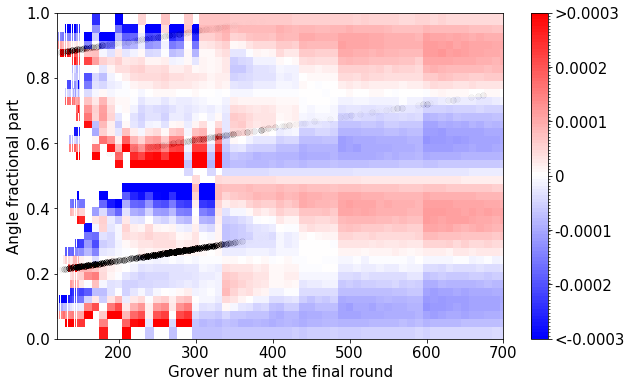

In [26]:
fig, ax = plt.subplots(figsize=(10,6))
levels = MaxNLocator(nbins=100).tick_values(-0.0003, 0.0003)
cmap = plt.colormaps['bwr']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
heatmap = ax.pcolor(nGsInterp, argInterp, biasMatInterp, cmap="bwr", norm=norm)
cbar = fig.colorbar(heatmap, ax=ax) # カラーバー

ticks  = np.arange(-0.0003, 0.00031, 0.0001)
labels = ['<-0.0003', '-0.0002', '-0.0001', '0', '0.0001', '0.0002', '>0.0003']
cbar.set_ticks(ticks)
cbar.set_ticklabels(labels)
cbar.ax.tick_params(axis='y', labelsize=15)

ax.scatter(nGroversExp,angleFracExp, c="k", alpha=0.005)
ax.set_ylim(0,1)
ax.set_xlim(120,700)
ax.set_xlabel("Grover num at the final round", fontsize=15)
ax.set_ylabel("Angle fractional part", fontsize=15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

plt.savefig("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230914_Bias_VariousNGrovAngleFrac/BiasHeatmap&NGrovFracAngleScatter_p0.2505.png")
plt.show()

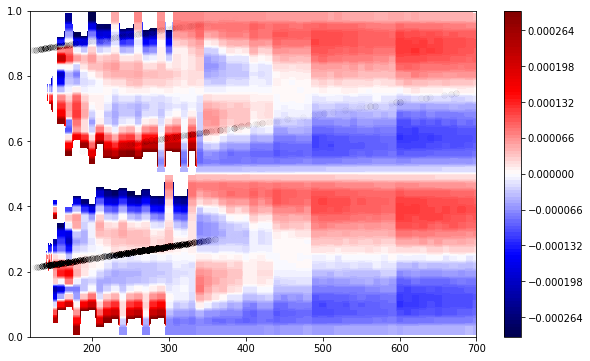

In [58]:
fig, ax1 = plt.subplots(1,figsize=(10,6))

levels = MaxNLocator(nbins=100).tick_values(-0.0003, 0.0003)

ax1.contourf(nGsInterp, argInterp, biasMatInterp, cmap="seismic", levels=levels)    #等高線表示
cntr1 = ax1.contourf(nGsInterp, argInterp, biasMatInterp, cmap="seismic", levels=levels)
fig.colorbar(cntr1, ax=ax1)

#ax1 = plt.colorbar(label="contour level")

ax1.scatter(nGroversExp,angleFracExp, c="k", alpha=0.005)
ax1.set_ylim(0,1)
ax1.set_xlim(120,700)

plt.show()

In [7]:
resDf[resDf["nGrover"]==300]

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
1800,300.0,100.0,0.024390,-6.898673e-05,10000.0,10000.0
1801,300.0,100.0,0.048780,-7.059000e-05,10000.0,10000.0
1802,300.0,100.0,0.073171,-4.162464e-05,10000.0,10000.0
1803,300.0,100.0,0.097561,-1.060669e-05,10000.0,10000.0
1804,300.0,100.0,0.121951,4.693590e-07,10000.0,10000.0
1805,300.0,100.0,0.146341,-1.504399e-05,10000.0,10000.0
1806,300.0,100.0,0.170732,-2.423767e-05,10000.0,10000.0
1807,300.0,100.0,0.195122,-2.952179e-05,10000.0,10000.0
1808,300.0,100.0,0.219512,-2.709955e-05,10000.0,10000.0
1809,300.0,100.0,0.243902,-8.712436e-06,10000.0,10000.0
